In [23]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.settings.figdir = "../plots"
sc.set_figure_params(dpi=500, dpi_save=500)

In [2]:
adata = sc.read_h5ad("/home/icb/alessandro.palma/environment/collab-goettgens-SFC/project_folder/output/loops/data/loop5/adata_500k.h5ad")

In [3]:
sc.pp.subsample(adata, n_obs=1_000_000)

In [4]:
# sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

In [5]:
adata.obs.experiment_number = adata.obs.experiment_number.astype("category")

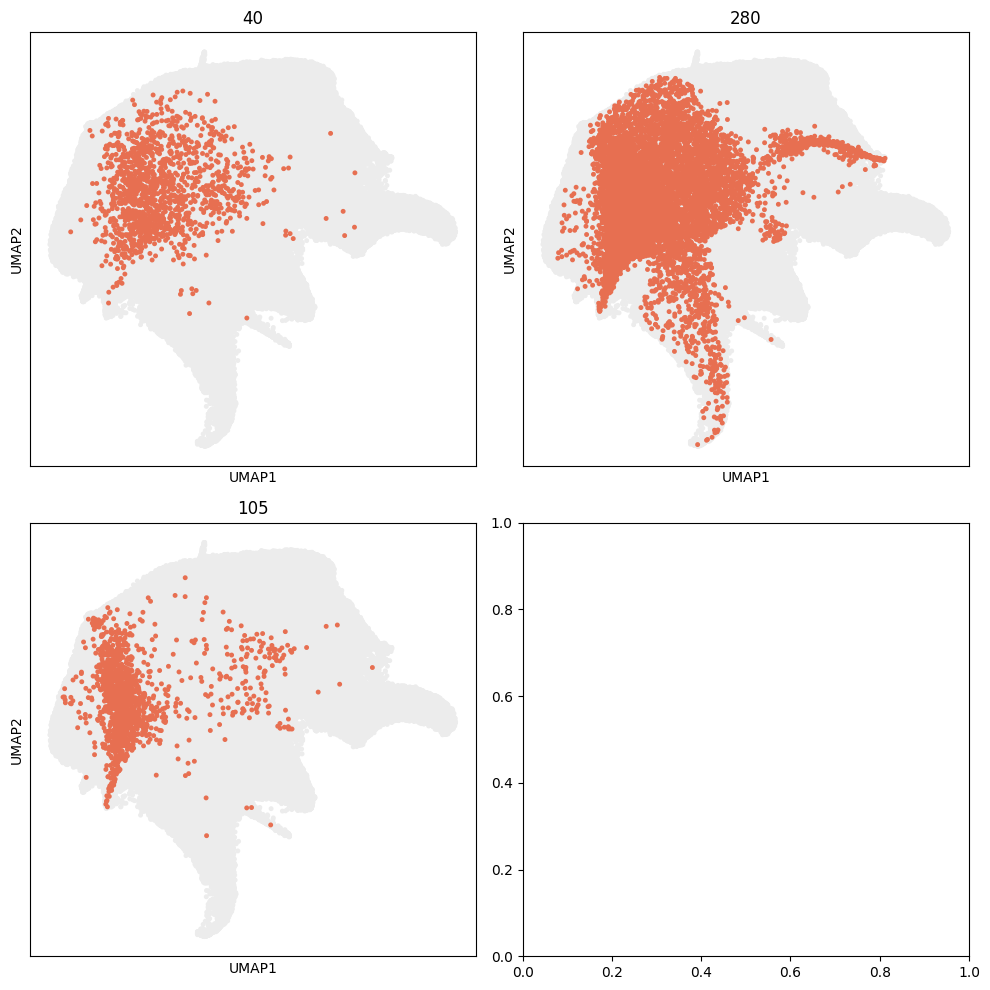

In [6]:
categories = adata.obs["experiment_number"].cat.categories
palette = {cat: "#d3d3d3" for cat in categories}  # default gray for all
palette["40"] = "#e76f51"
palette["280"] = "#e76f51"
palette["105"] = "#e76f51"

groups = ["40", "280", "105"]
fig, axes = plt.subplots(2, 2, figsize=(10, 10))

for ax, grp in zip(axes.flat, groups):
    sc.pl.umap(
        adata,
        color="experiment_number",
        groups=[grp],
        palette=palette,   # full dict covering all categories, not a subset
        s=50,
        ax=ax,
        show=False,
        title=grp,
        legend_loc=None,
        na_color="#ececec",
    )
plt.tight_layout()
plt.show()

/tmp/ipykernel_3861330/4019067451.py:17: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


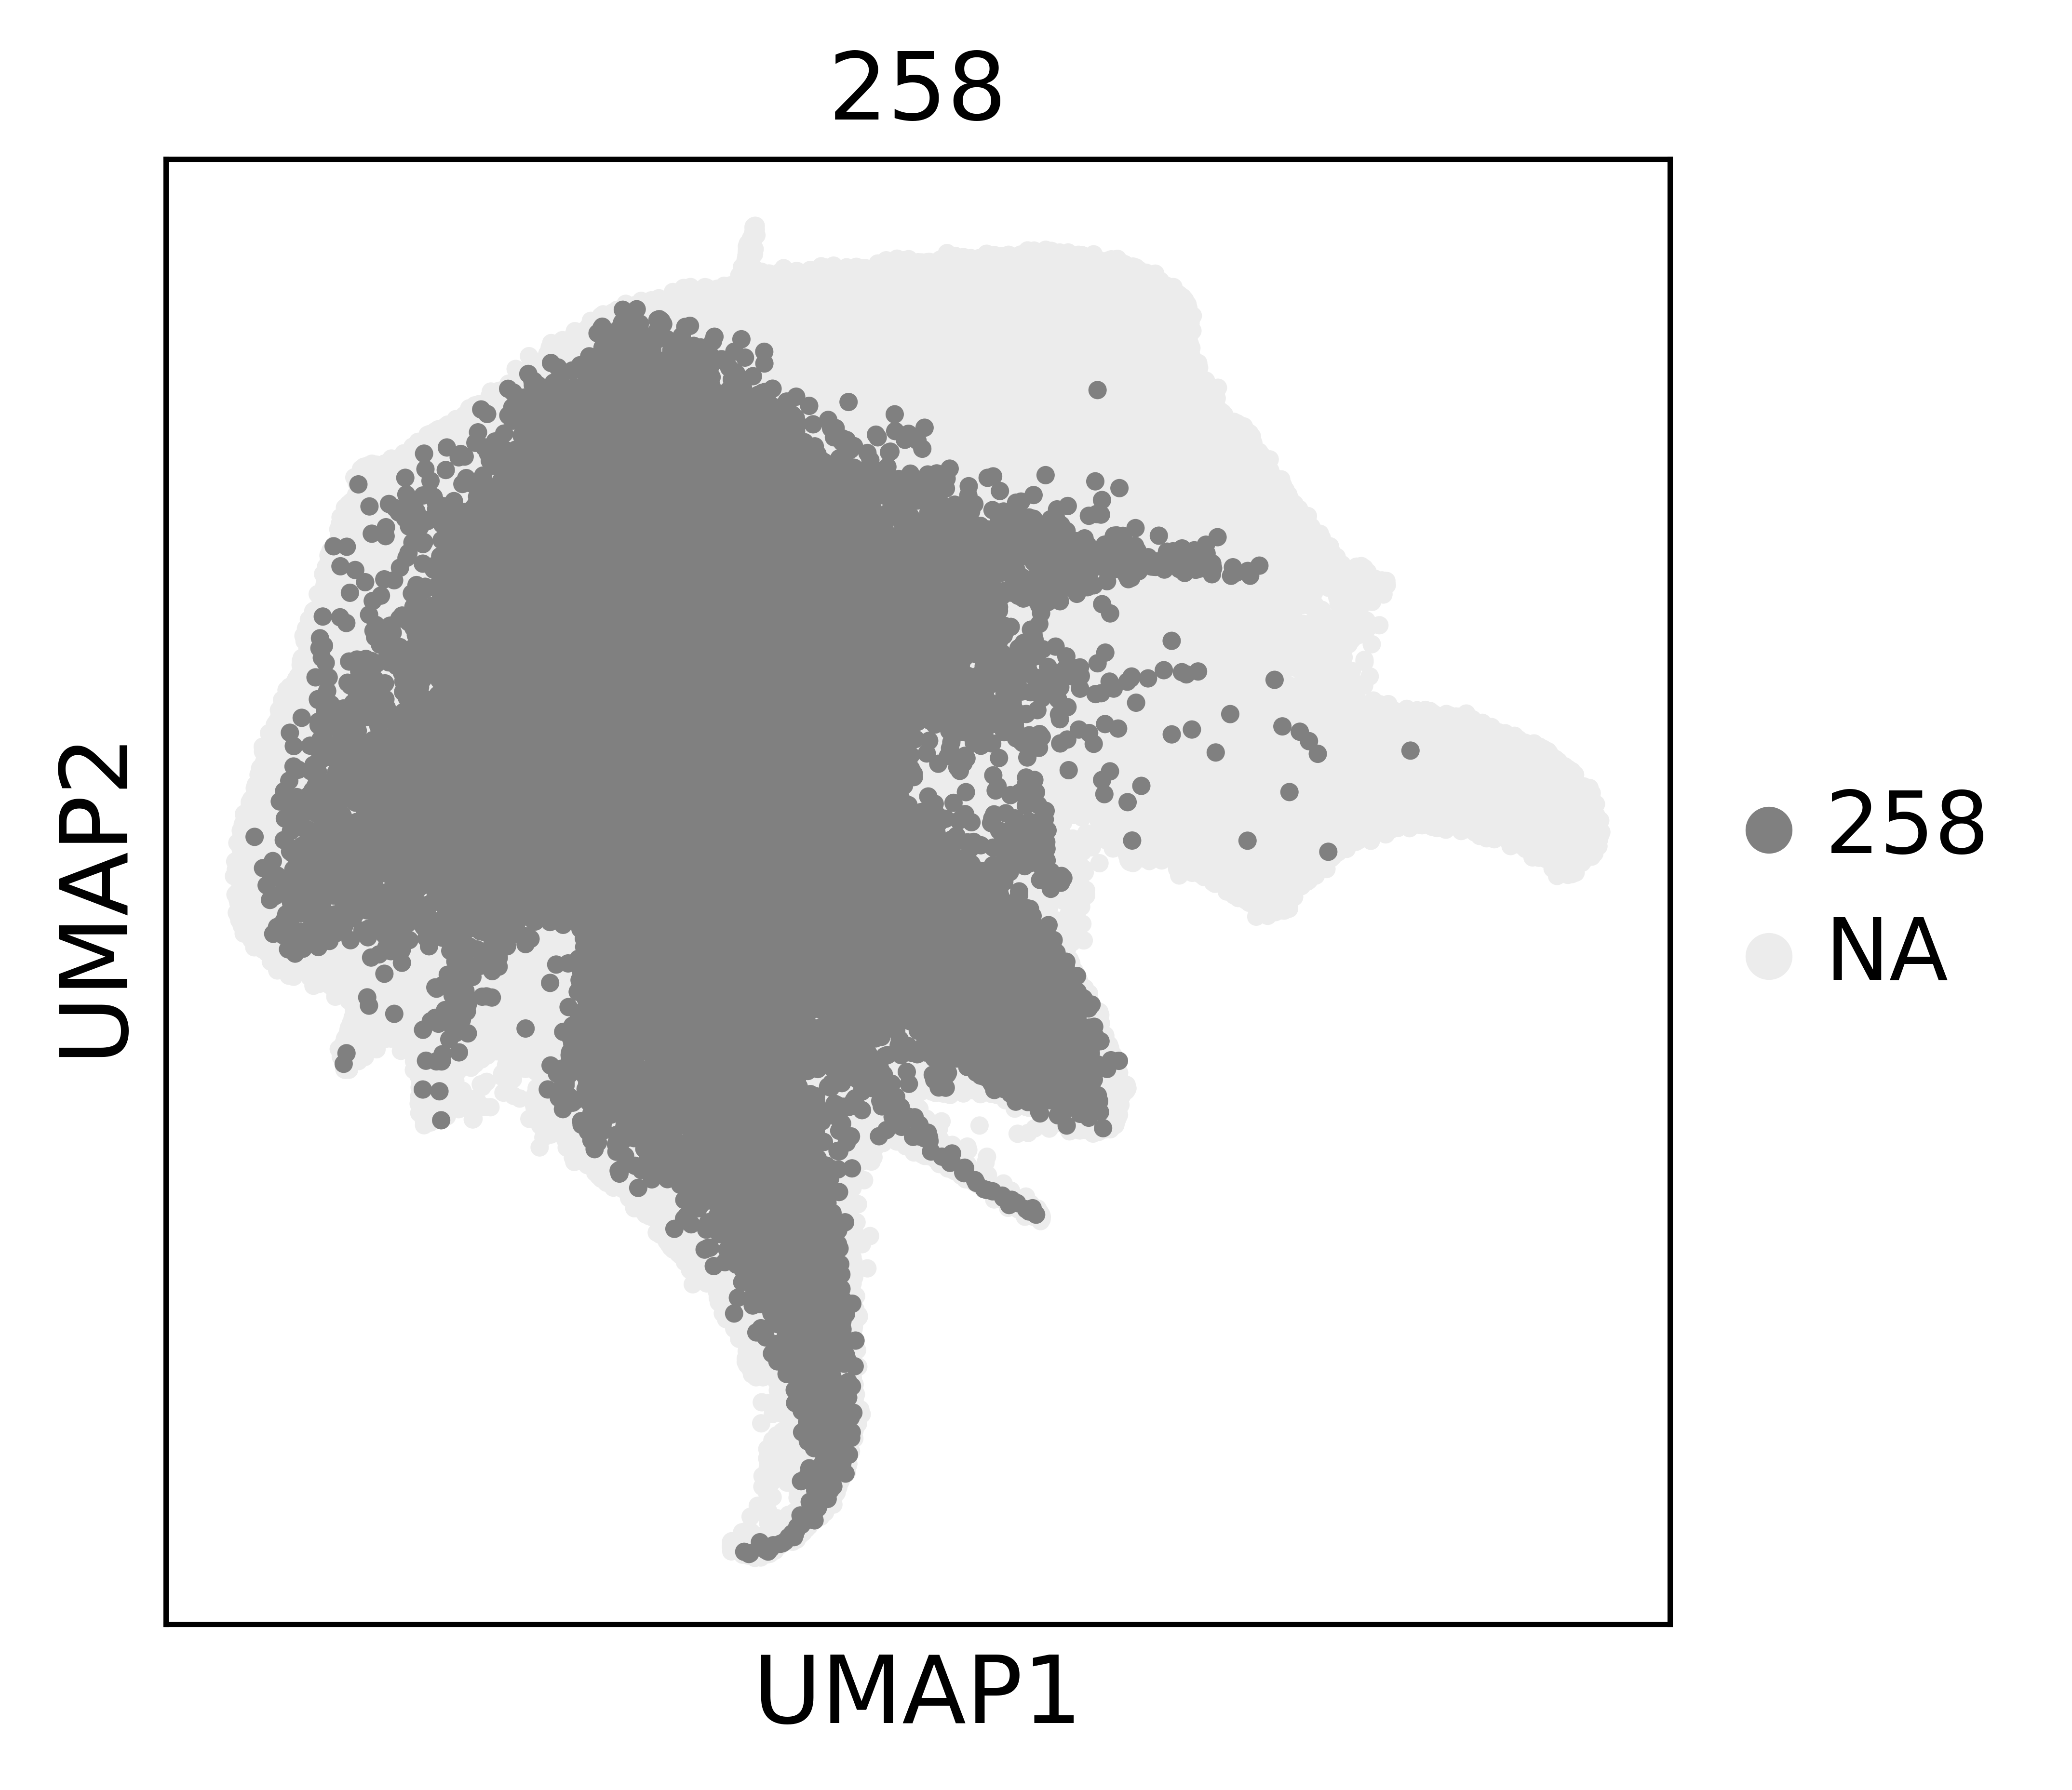

/tmp/ipykernel_3861330/4019067451.py:17: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


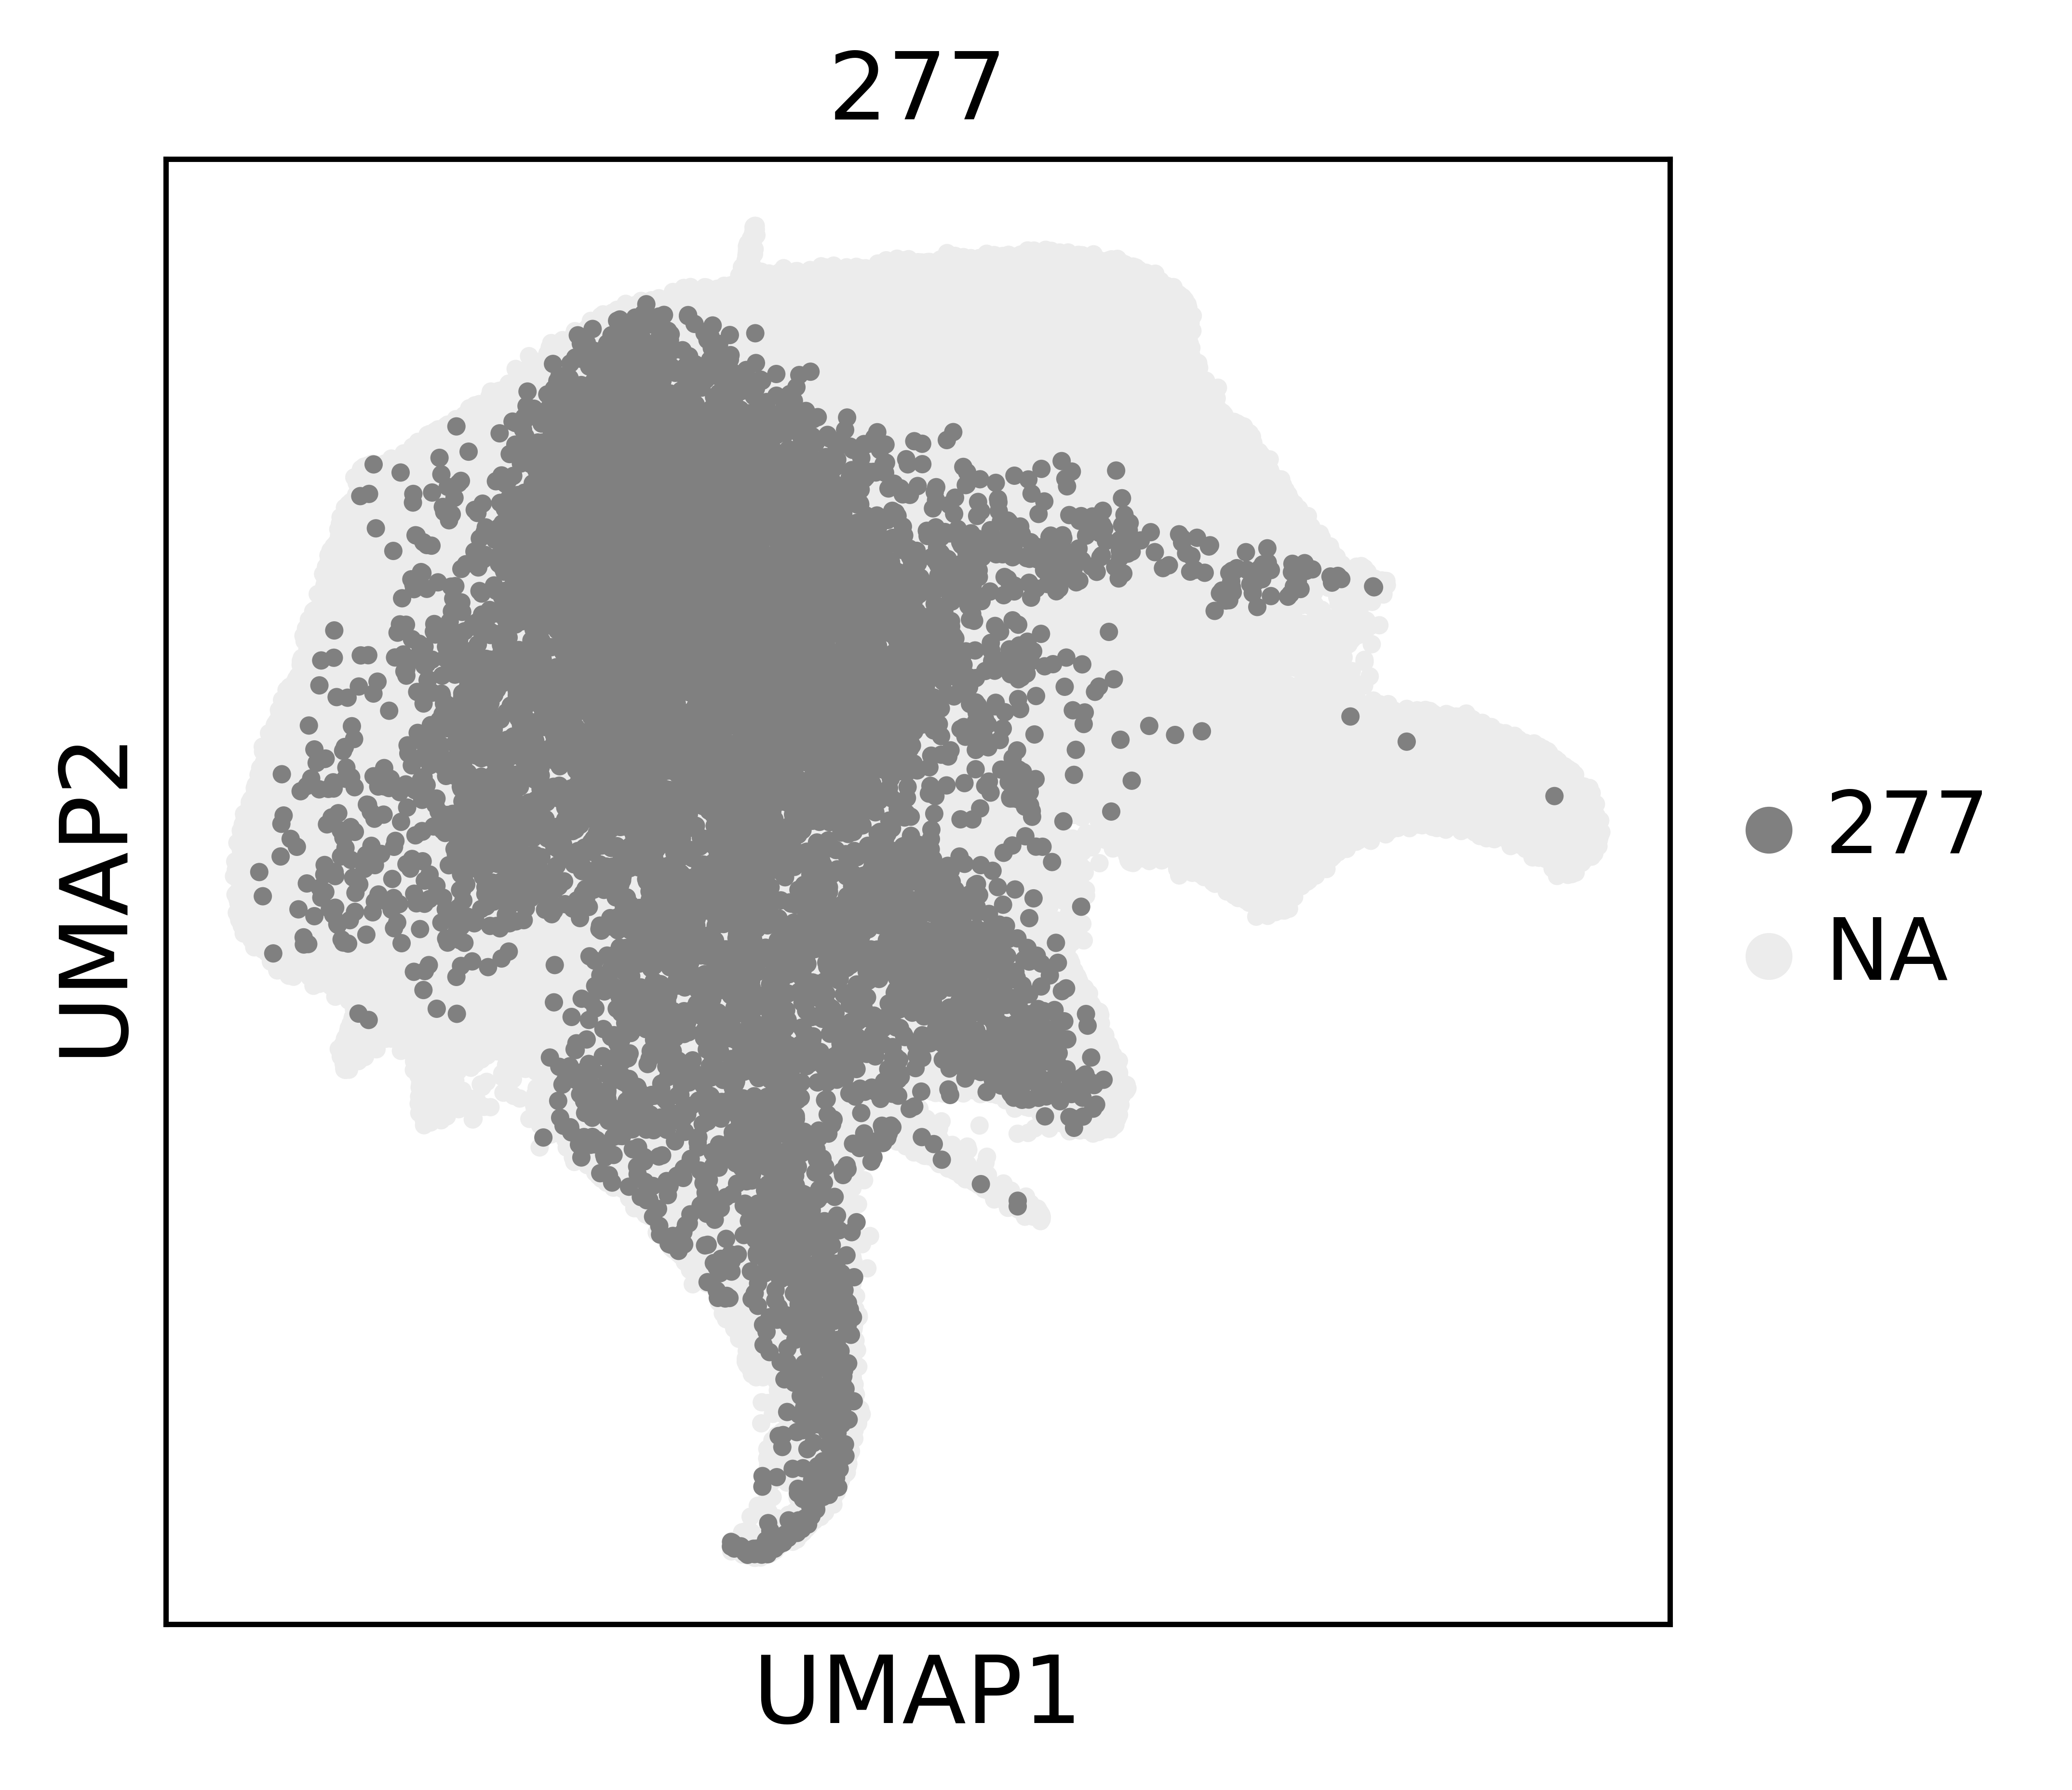

In [24]:
categories = adata.obs["experiment_number"].cat.categories
palette = {cat: "#d3d3d3" for cat in categories}
# palette["158"] = "#e76f51"
# palette["205"] = "#e76f51"
palette["258"] = "gray"
palette["277"] = "gray"

groups = [
    # "158", 
    # "205",
    "258",
    "277"
]
# fig, axes = plt.subplots(2, 1, figsize=(10, 10))

for ax, grp in zip(axes.flat, groups):
    sc.pl.umap(
        adata,
        color="experiment_number",
        groups=[grp],
        palette=palette,
        s=30,
        title=grp,
        save=f"_{grp}.png",
        na_color="#ececec",  # light gray, distinct from palette's #d3d3d3
    )